<a href="https://colab.research.google.com/github/alejagamez26/DS/blob/main/TelecomX_LATAM_Alejandra_Gamez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [1]:
import pandas as pd

In [2]:
df = pd.read_json('/content/TelecomX_Data.json')

In [4]:
df = pd.DataFrame(df)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [8]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [9]:
print("=== VALORES NULOS ===")
print(df.isnull().sum())

=== VALORES NULOS ===
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


In [11]:
print("=== DUPLICADOS ===")
print(f"Filas duplicadas (basado en customerID y Churn): {df.duplicated(subset=['customerID', 'Churn']).sum()}")


=== DUPLICADOS ===
Filas duplicadas (basado en customerID y Churn): 0


In [12]:

df_expandido = pd.json_normalize(df.to_dict(orient="records"))

print("=== COLUMNAS DESPUÉS DE EXPANDIR ===")
print(df_expandido.columns.tolist())
print(df_expandido.shape)

=== COLUMNAS DESPUÉS DE EXPANDIR ===
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']
(7267, 21)


In [13]:
print("=== CHURN ===")
print(df_expandido["Churn"].value_counts())

print("\n=== CONTRATO ===")
print(df_expandido["account.Contract"].value_counts())

print("\n=== INTERNET SERVICE ===")
print(df_expandido["internet.InternetService"].value_counts())

print("\n=== CHARGES.TOTAL (tipo) ===")
print(df_expandido["account.Charges.Total"].dtype)
print(df_expandido["account.Charges.Total"].sample(5))

=== CHURN ===
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

=== CONTRATO ===
account.Contract
Month-to-month    4005
Two year          1743
One year          1519
Name: count, dtype: int64

=== INTERNET SERVICE ===
internet.InternetService
Fiber optic    3198
DSL            2488
No             1581
Name: count, dtype: int64

=== CHARGES.TOTAL (tipo) ===
object
6429    8065.65
3427       1902
5750       35.9
4959       81.7
2341     4438.2
Name: account.Charges.Total, dtype: object


In [14]:
df = df_expandido.copy()
print("Columnas listas:", df.shape)

Columnas listas: (7267, 21)


In [15]:
df = df[df["Churn"].str.strip() != ""]
print("Registros después de limpiar Churn:", len(df))
print(df["Churn"].value_counts())

Registros después de limpiar Churn: 7043
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [16]:
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

print("Tipo de dato:", df["account.Charges.Total"].dtype)
print("Nulos generados:", df["account.Charges.Total"].isnull().sum())

Tipo de dato: float64
Nulos generados: 11


In [17]:
df["account.Charges.Total"] = df["account.Charges.Total"].fillna(0)
print("Nulos restantes:", df["account.Charges.Total"].isnull().sum())

Nulos restantes: 0


In [18]:
print("=== DATASET LIMPIO ===")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"\nNulos por columna:\n{df.isnull().sum()}")
print(f"\nChurn:\n{df['Churn'].value_counts()}")
print(f"\nCharges.Total (tipo): {df['account.Charges.Total'].dtype}")

=== DATASET LIMPIO ===
Filas: 7043 | Columnas: 21

Nulos por columna:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Charges.Total (tipo): float64


In [19]:
# Calcular el cargo diario a partir del cargo mensual
df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

print("=== COLUMNA CREADA ===")
print(df[["customerID", "account.Charges.Monthly", "Cuentas_Diarias"]].head(10))
print(f"\nEstadísticas:")
print(df["Cuentas_Diarias"].describe().round(2))

=== COLUMNA CREADA ===
   customerID  account.Charges.Monthly  Cuentas_Diarias
0  0002-ORFBO                    65.60         2.186667
1  0003-MKNFE                    59.90         1.996667
2  0004-TLHLJ                    73.90         2.463333
3  0011-IGKFF                    98.00         3.266667
4  0013-EXCHZ                    83.90         2.796667
5  0013-MHZWF                    69.40         2.313333
6  0013-SMEOE                   109.70         3.656667
7  0014-BMAQU                    84.65         2.821667
8  0015-UOCOJ                    48.20         1.606667
9  0016-QLJIS                    90.45         3.015000

Estadísticas:
count    7043.00
mean        2.16
std         1.00
min         0.61
25%         1.18
50%         2.34
75%         2.99
max         3.96
Name: Cuentas_Diarias, dtype: float64


In [20]:
df = df.rename(columns={
    "customerID"                  : "id_cliente",
    "Churn"                       : "evasion",
    "customer.gender"             : "genero",
    "customer.SeniorCitizen"      : "adulto_mayor",
    "customer.Partner"            : "pareja",
    "customer.Dependents"         : "dependientes",
    "customer.tenure"             : "meses_contrato",
    "phone.PhoneService"          : "servicio_telefono",
    "phone.MultipleLines"         : "multiples_lineas",
    "internet.InternetService"    : "servicio_internet",
    "internet.OnlineSecurity"     : "seguridad_online",
    "internet.OnlineBackup"       : "respaldo_online",
    "internet.DeviceProtection"   : "proteccion_dispositivo",
    "internet.TechSupport"        : "soporte_tecnico",
    "internet.StreamingTV"        : "streaming_tv",
    "internet.StreamingMovies"    : "streaming_peliculas",
    "account.Contract"            : "tipo_contrato",
    "account.PaperlessBilling"    : "factura_digital",
    "account.PaymentMethod"       : "metodo_pago",
    "account.Charges.Monthly"     : "cargo_mensual",
    "account.Charges.Total"       : "cargo_total"
})

print("Columnas renombradas:", df.columns.tolist())

Columnas renombradas: ['id_cliente', 'evasion', 'genero', 'adulto_mayor', 'pareja', 'dependientes', 'meses_contrato', 'servicio_telefono', 'multiples_lineas', 'servicio_internet', 'seguridad_online', 'respaldo_online', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'tipo_contrato', 'factura_digital', 'metodo_pago', 'cargo_mensual', 'cargo_total', 'Cuentas_Diarias']


In [21]:
columnas_binarias = [
    "evasion", "pareja", "dependientes", "servicio_telefono",
    "multiples_lineas", "seguridad_online", "respaldo_online",
    "proteccion_dispositivo", "soporte_tecnico", "streaming_tv",
    "streaming_peliculas", "factura_digital"
]

for col in columnas_binarias:
    df[col] = df[col].map({"Yes": 1, "No": 0})

print("=== VERIFICACIÓN BINARIA ===")
print(df[columnas_binarias].head())

=== VERIFICACIÓN BINARIA ===
   evasion  pareja  dependientes  servicio_telefono  multiples_lineas  \
0        0       1             1                  1               0.0   
1        0       0             0                  1               1.0   
2        1       0             0                  1               0.0   
3        1       1             0                  1               0.0   
4        1       1             0                  1               0.0   

   seguridad_online  respaldo_online  proteccion_dispositivo  soporte_tecnico  \
0               0.0              1.0                     0.0              1.0   
1               0.0              0.0                     0.0              0.0   
2               0.0              0.0                     1.0              0.0   
3               0.0              1.0                     1.0              0.0   
4               0.0              0.0                     0.0              1.0   

   streaming_tv  streaming_peliculas  factura

In [22]:
df["genero"] = df["genero"].map({"Male": "Masculino", "Female": "Femenino"})

df["servicio_internet"] = df["servicio_internet"].map({
    "Fiber optic": "Fibra óptica",
    "DSL"        : "DSL",
    "No"         : "Sin internet"
})

df["tipo_contrato"] = df["tipo_contrato"].map({
    "Month-to-month": "Mes a mes",
    "One year"      : "Un año",
    "Two year"      : "Dos años"
})

df["metodo_pago"] = df["metodo_pago"].map({
    "Electronic check"          : "Cheque electrónico",
    "Mailed check"              : "Cheque por correo",
    "Bank transfer (automatic)" : "Transferencia bancaria",
    "Credit card (automatic)"   : "Tarjeta de crédito"
})

print("=== VERIFICACIÓN CATEGÓRICAS ===")
print(df[["genero", "servicio_internet", "tipo_contrato", "metodo_pago"]].head())

=== VERIFICACIÓN CATEGÓRICAS ===
      genero servicio_internet tipo_contrato         metodo_pago
0   Femenino               DSL        Un año   Cheque por correo
1  Masculino               DSL     Mes a mes   Cheque por correo
2  Masculino      Fibra óptica     Mes a mes  Cheque electrónico
3  Masculino      Fibra óptica     Mes a mes  Cheque electrónico
4   Femenino      Fibra óptica     Mes a mes   Cheque por correo


In [23]:
print("=== DATASET FINAL ===")
print(df.shape)
print(df.head())

=== DATASET FINAL ===
(7043, 22)
   id_cliente  evasion     genero  adulto_mayor  pareja  dependientes  \
0  0002-ORFBO        0   Femenino             0       1             1   
1  0003-MKNFE        0  Masculino             0       0             0   
2  0004-TLHLJ        1  Masculino             0       0             0   
3  0011-IGKFF        1  Masculino             1       1             0   
4  0013-EXCHZ        1   Femenino             1       1             0   

   meses_contrato  servicio_telefono  multiples_lineas servicio_internet  ...  \
0               9                  1               0.0               DSL  ...   
1               9                  1               1.0               DSL  ...   
2               4                  1               0.0      Fibra óptica  ...   
3              13                  1               0.0      Fibra óptica  ...   
4               3                  1               0.0      Fibra óptica  ...   

   proteccion_dispositivo  soporte_tecnic

#📊 Carga y análisis

In [24]:
df.describe()

,evasion,adulto_mayor,pareja,dependientes,meses_contrato,servicio_telefono,multiples_lineas,seguridad_online,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,factura_digital,cargo_mensual,cargo_total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,5517.000000,5517.000000,5517.000000,5517.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.467065,0.365960,0.440276,0.439007,0.370491,0.490665,0.495197,0.592219,64.761692,2279.734304,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.498953,0.481742,0.496465,0.496311,0.482980,0.499958,0.500022,0.491457,30.090047,2266.794470,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


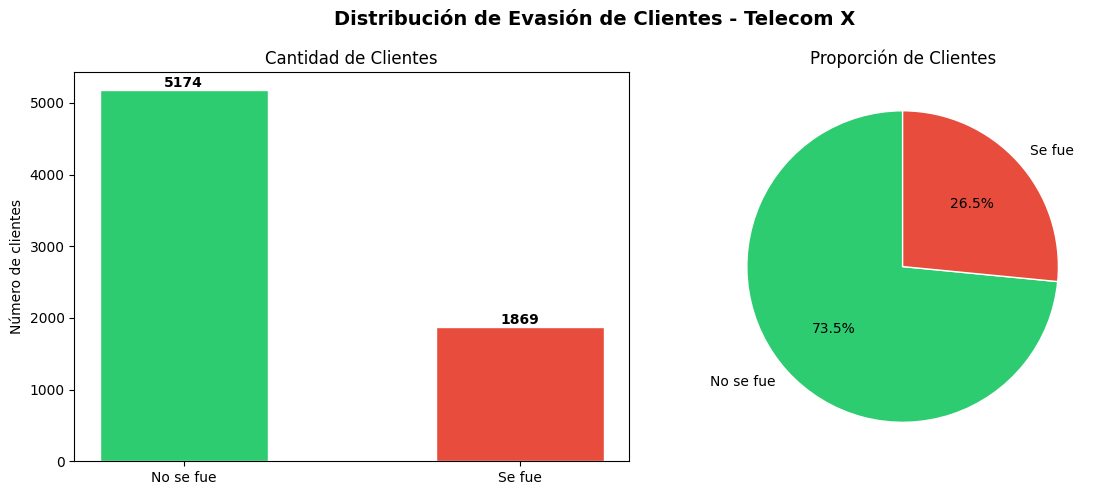

Total clientes: 7043
Clientes que se fueron: 1869 (26.54%)
Clientes que permanecieron: 5174 (73.46000000000001%)


In [25]:
import matplotlib.pyplot as plt

# Calcular conteos y porcentajes
conteo = df["evasion"].value_counts()
etiquetas = ["No se fue", "Se fue"]
colores = ["#2ecc71", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribución de Evasión de Clientes - Telecom X", fontsize=14, fontweight="bold")

# --- Gráfico 1: Barras ---
axes[0].bar(etiquetas, conteo, color=colores, edgecolor="white", width=0.5)
axes[0].set_title("Cantidad de Clientes")
axes[0].set_ylabel("Número de clientes")
for i, v in enumerate(conteo):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

# --- Gráfico 2: Torta ---
axes[1].pie(conteo, labels=etiquetas, colors=colores, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proporción de Clientes")

plt.tight_layout()
plt.show()

# Resumen en texto
total = len(df)
tasa_evasion = (conteo[1] / total * 100).round(2)
print(f"Total clientes: {total}")
print(f"Clientes que se fueron: {conteo[1]} ({tasa_evasion}%)")
print(f"Clientes que permanecieron: {conteo[0]} ({(100 - tasa_evasion)}%)")

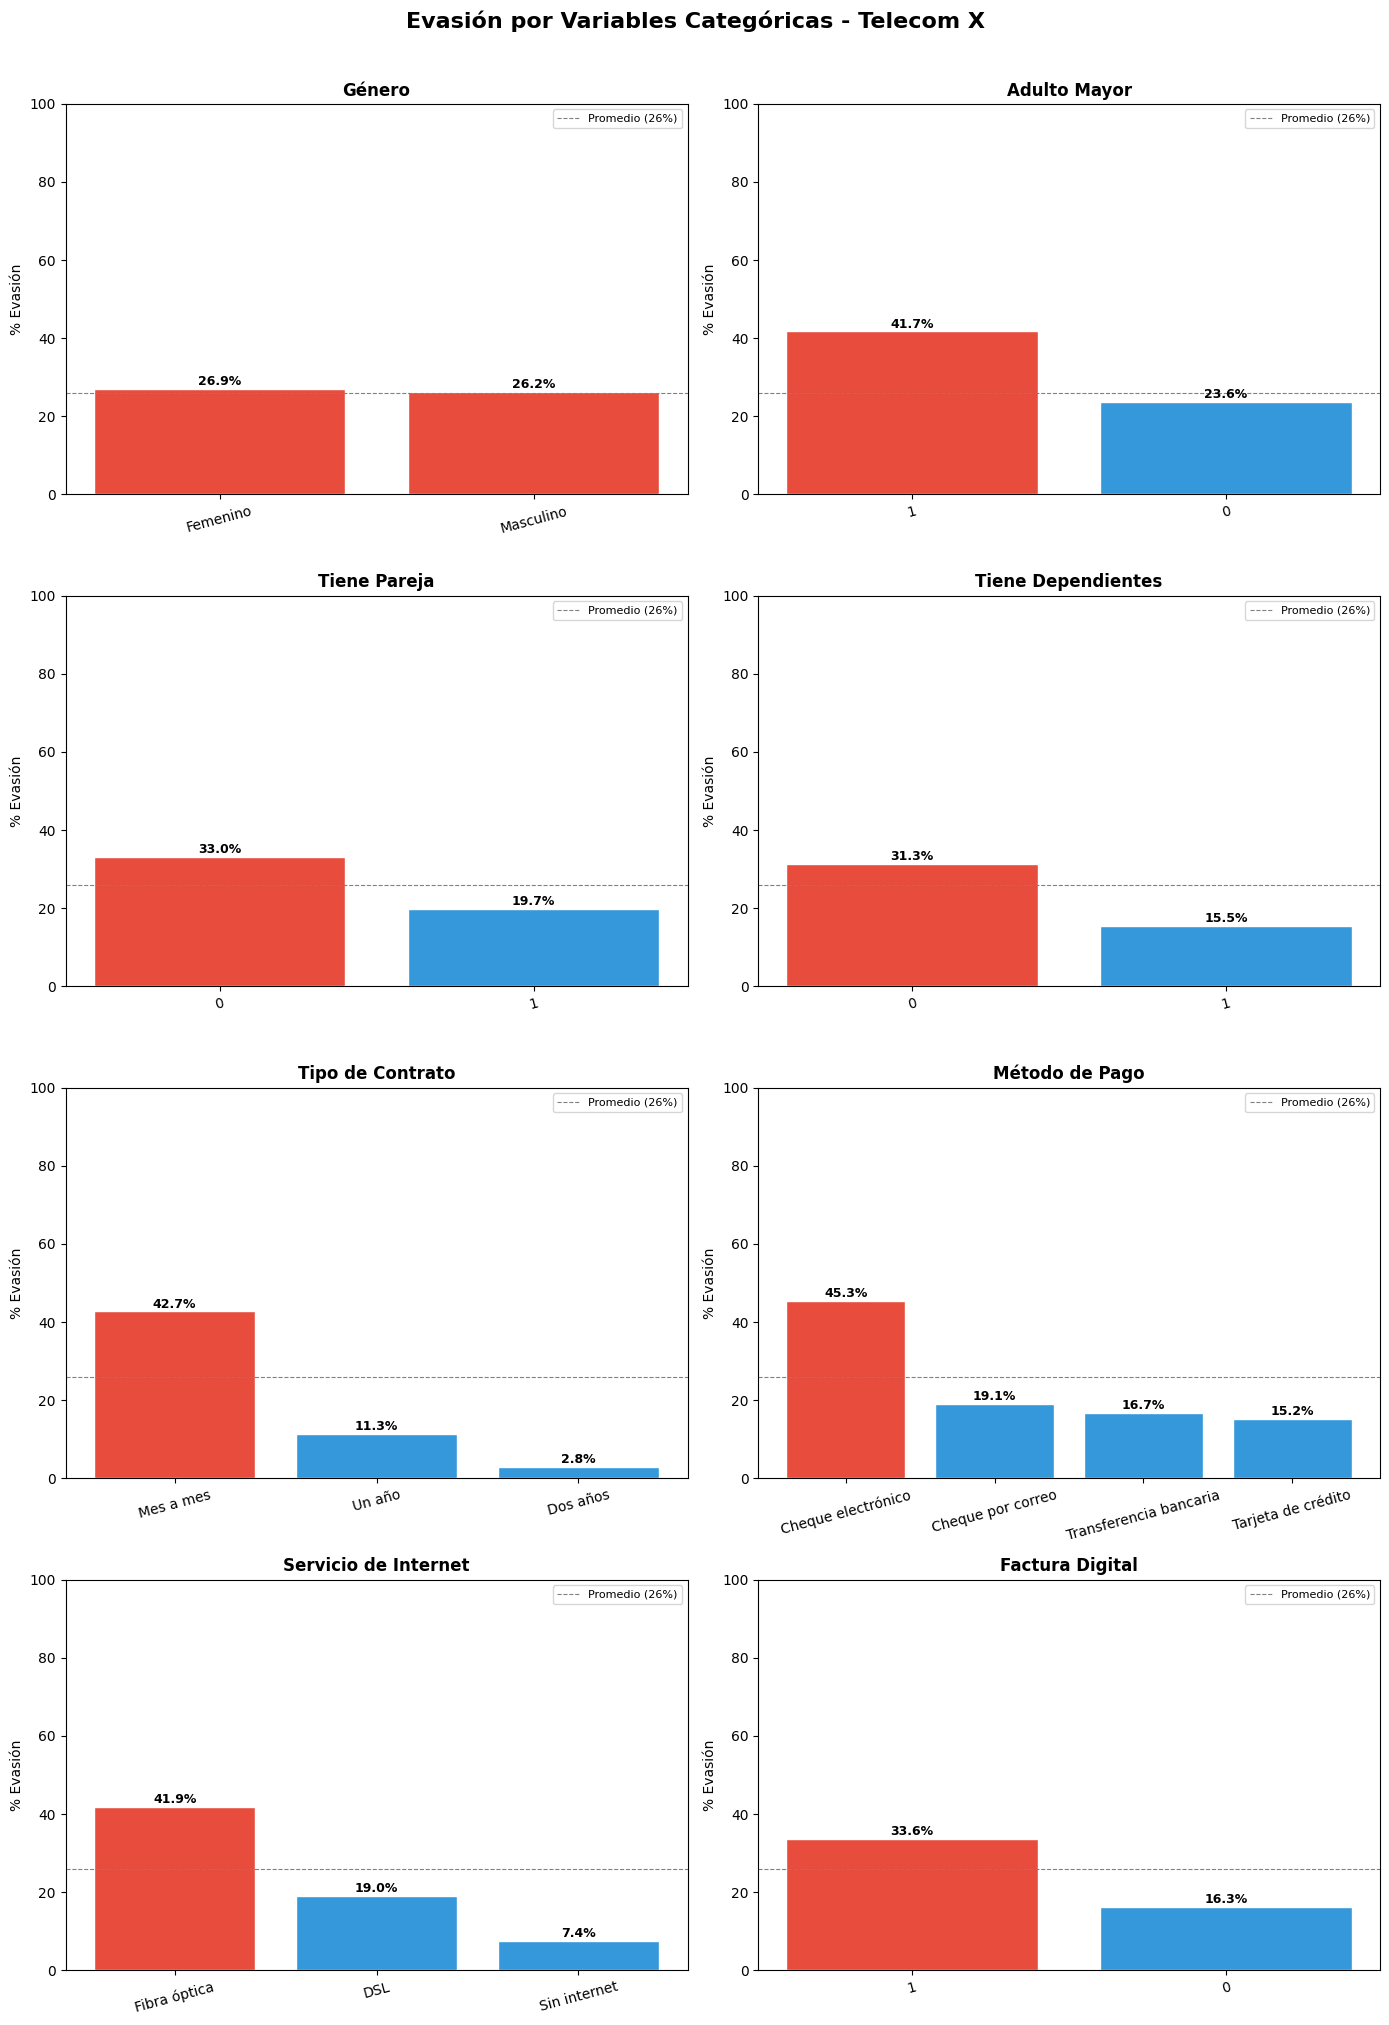

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    ("genero",            "Género"),
    ("adulto_mayor",      "Adulto Mayor"),
    ("pareja",            "Tiene Pareja"),
    ("dependientes",      "Tiene Dependientes"),
    ("tipo_contrato",     "Tipo de Contrato"),
    ("metodo_pago",       "Método de Pago"),
    ("servicio_internet", "Servicio de Internet"),
    ("factura_digital",   "Factura Digital"),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle("Evasión por Variables Categóricas - Telecom X", fontsize=16, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, (col, titulo) in enumerate(variables):
    tabla = df.groupby(col)["evasion"].mean().mul(100).round(1).sort_values(ascending=False)
    colores = ["#e74c3c" if v > 26 else "#3498db" for v in tabla.values]

    axes[i].bar(tabla.index.astype(str), tabla.values, color=colores, edgecolor="white")
    axes[i].set_title(titulo, fontweight="bold")
    axes[i].set_ylabel("% Evasión")
    axes[i].set_ylim(0, 100)
    axes[i].axhline(y=26, color="gray", linestyle="--", linewidth=0.8, label="Promedio (26%)")
    axes[i].legend(fontsize=8)
    for j, v in enumerate(tabla.values):
        axes[i].text(j, v + 1, f"{v}%", ha="center", fontsize=9, fontweight="bold")
    axes[i].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_146/538111597.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i*2+1].boxplot(datos_box, patch_artist=True,
/tmp/ipykernel_146/538111597.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i*2+1].boxplot(datos_box, patch_artist=True,
/tmp/ipykernel_146/538111597.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i*2+1].boxplot(datos_box, patch_artist=True,
/tmp/ipykernel_146/538111597.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax

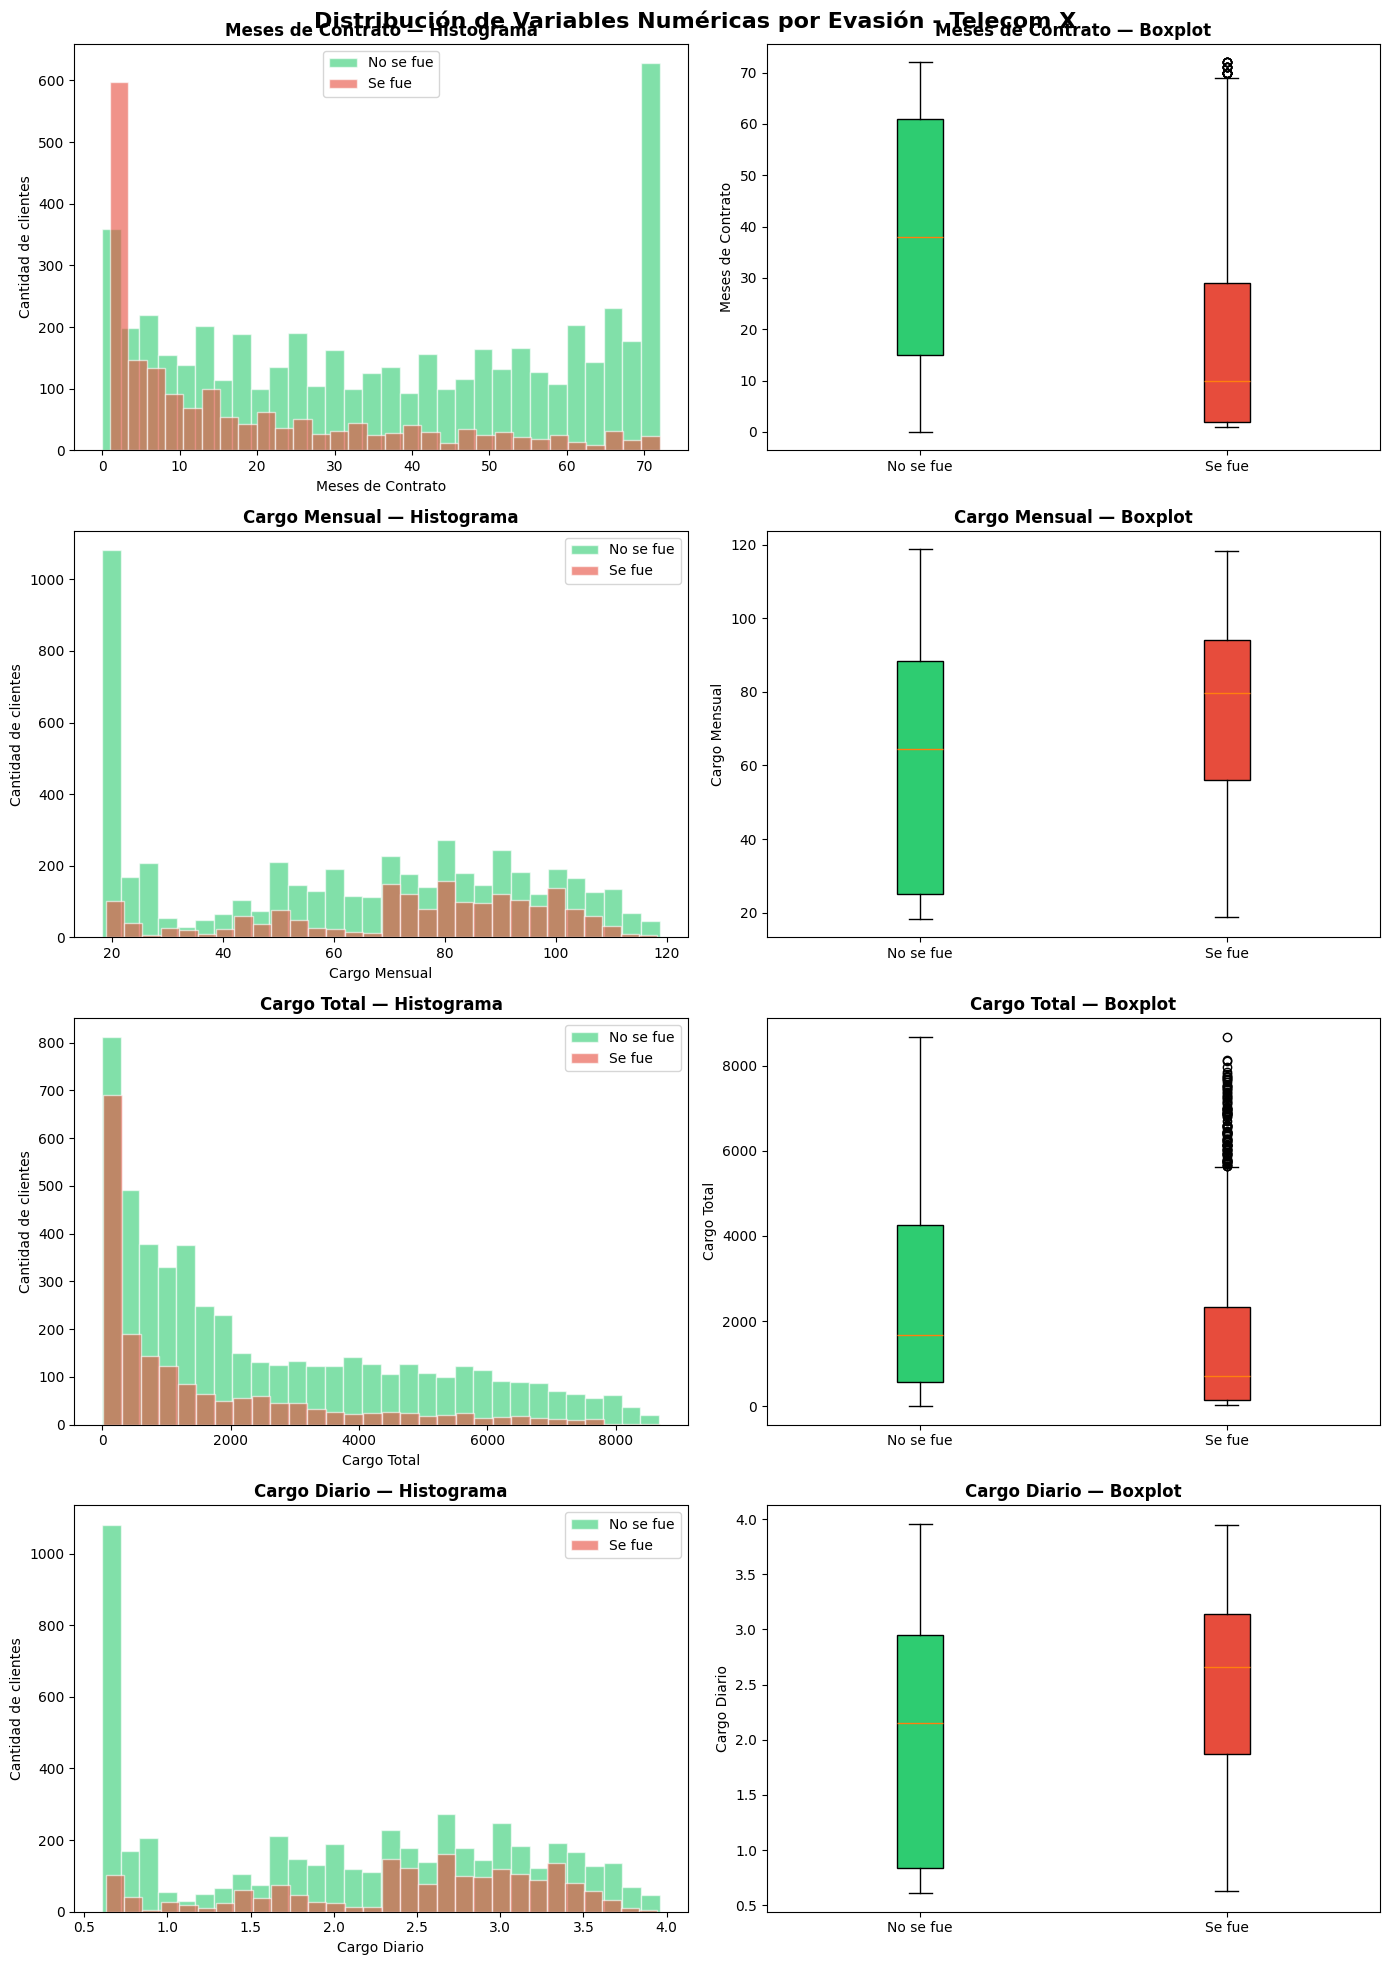

=== PROMEDIOS POR GRUPO ===
Meses de Contrato    → No se fue: 37.57 | Se fue: 17.98
Cargo Mensual        → No se fue: 61.27 | Se fue: 74.44
Cargo Total          → No se fue: 2549.91 | Se fue: 1531.8
Cargo Diario         → No se fue: 2.04 | Se fue: 2.48


In [27]:
variables_num = [
    ("meses_contrato",  "Meses de Contrato"),
    ("cargo_mensual",   "Cargo Mensual"),
    ("cargo_total",     "Cargo Total"),
    ("Cuentas_Diarias", "Cargo Diario"),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle("Distribución de Variables Numéricas por Evasión - Telecom X",
             fontsize=16, fontweight="bold")
axes = axes.flatten()

colores = {0: "#2ecc71", 1: "#e74c3c"}
etiquetas = {0: "No se fue", 1: "Se fue"}

for i, (col, titulo) in enumerate(variables_num):

    # --- Histograma ---
    for grupo in [0, 1]:
        datos = df[df["evasion"] == grupo][col]
        axes[i*2].hist(datos, bins=30, alpha=0.6,
                       color=colores[grupo], label=etiquetas[grupo], edgecolor="white")
    axes[i*2].set_title(f"{titulo} — Histograma", fontweight="bold")
    axes[i*2].set_xlabel(titulo)
    axes[i*2].set_ylabel("Cantidad de clientes")
    axes[i*2].legend()

    # --- Boxplot ---
    datos_box = [df[df["evasion"] == 0][col], df[df["evasion"] == 1][col]]
    bp = axes[i*2+1].boxplot(datos_box, patch_artist=True,
                              labels=["No se fue", "Se fue"])
    bp["boxes"][0].set_facecolor("#2ecc71")
    bp["boxes"][1].set_facecolor("#e74c3c")
    axes[i*2+1].set_title(f"{titulo} — Boxplot", fontweight="bold")
    axes[i*2+1].set_ylabel(titulo)

plt.tight_layout()
plt.show()

# Resumen estadístico
print("=== PROMEDIOS POR GRUPO ===")
for col, titulo in variables_num:
    media_no = df[df["evasion"] == 0][col].mean().round(2)
    media_si = df[df["evasion"] == 1][col].mean().round(2)
    print(f"{titulo:20} → No se fue: {media_no} | Se fue: {media_si}")

#📄Informe final

# 📊 Telecom X — Análisis de Evasión de Clientes

## 1. Introducción

Telecom X enfrenta una tasa de cancelación del **26.5%**, lo que representa una pérdida
significativa de ingresos y clientes. El objetivo de este análisis es identificar los
factores que influyen en la evasión de clientes (*churn*) utilizando técnicas de
Análisis Exploratorio de Datos (EDA).

**Fuente de datos:** API de Telecom X — 7,267 registros iniciales, 21 variables.

**Herramientas utilizadas:** Python, Pandas, Matplotlib, Seaborn.

## 2. Limpieza y Tratamiento de Datos (ETL)

Los datos fueron cargados desde una API en formato JSON y procesados en las
siguientes etapas:

| Problema encontrado | Acción tomada |
|---|---|
| Columnas anidadas (customer, phone, internet, account) | Aplanadas con `pd.json_normalize` |
| 224 registros con Churn vacío | Eliminados → dataset final: 7,043 registros |
| `Charges.Total` en formato texto | Convertido a `float64` con `pd.to_numeric` |
| Variables binarias en Yes/No | Convertidas a 1/0 |
| Columnas y valores en inglés | Traducidos al español |
| Nueva variable creada | `Cuentas_Diarias` = cargo mensual / 30 |

## 3. Análisis Exploratorio de Datos

### 3.1 Distribución de Evasión
De los 7,043 clientes analizados, **5,174 (73.5%)** permanecieron y
**1,869 (26.5%)** cancelaron el servicio. La tasa de evasión es considerablemente
alta para el sector de telecomunicaciones.

### 3.2 Evasión por Variables Categóricas
Se analizaron 8 variables categóricas comparando su tasa de evasión contra
el promedio general del 26.5%.

### 3.3 Evasión por Variables Numéricas
Se compararon las distribuciones de meses de contrato, cargo mensual,
cargo total y cargo diario entre clientes que se fueron y los que permanecieron.

## 4. Conclusiones e Insights

### 🔴 Factores de alto riesgo de evasión:

- **Contrato mes a mes:** presentan la tasa de evasión más alta.
  Los contratos anuales y bianuales retienen significativamente más clientes.

- **Servicio de Fibra óptica:** a pesar de ser el servicio premium, tiene
  mayor evasión, lo que sugiere insatisfacción con la relación precio-calidad.

- **Cheque electrónico:** el método de pago con mayor evasión, posiblemente
  asociado a clientes menos comprometidos con el servicio.

- **Clientes nuevos (pocos meses de contrato):** los primeros meses son
  críticos — la mayoría de las cancelaciones ocurren en clientes recientes.

- **Cargo mensual alto:** los clientes que se van pagan más por mes,
  pero acumulan menos en cargo total, confirmando que se van pronto.

### 🟢 Factores asociados a la retención:

- Tener **pareja o dependientes** reduce la probabilidad de evasión.
- Contratar **soporte técnico y seguridad online** está asociado a mayor fidelidad.
- Clientes con **más antigüedad** tienen mucho menor tendencia a cancelar.

## 5. Recomendaciones Estratégicas

| # | Recomendación | Basada en |
|---|---|---|
| 1 | **Incentivar contratos anuales** desde el inicio con descuentos o beneficios | Alto churn en contratos mes a mes |
| 2 | **Programa de bienvenida** para los primeros 3 meses de contrato | Mayoría de cancelaciones en clientes nuevos |
| 3 | **Revisar precios de Fibra óptica** o mejorar la percepción de valor | Alta evasión pese a ser servicio premium |
| 4 | **Incentivar pagos automáticos** (tarjeta o transferencia) sobre cheque electrónico | Cheque electrónico asociado a mayor evasión |
| 5 | **Ofrecer paquetes con soporte técnico y seguridad** como servicios base | Clientes con estos servicios evaden menos |
| 6 | **Modelo predictivo de churn** como siguiente paso para acciones proactivas | Patrones claros identificados en el EDA |

---
*Análisis realizado como parte del programa de formación en Data Science — Telecom X* 🚀